<a href="https://colab.research.google.com/github/rohkdev/ClimateModelingResearch/blob/main/Task%207%3A%20Train%20%26%20Test%20Percent%20Warm%20Nights.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Cell 1: Imports and Data Loading
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load your dataset from Task 5
df = pd.read_csv("Random_Forest_Modeling_Data.csv")

In [ ]:
# Cell 2: Step 1 - Check the Dataset
print("--- Step 1: Dataset Summary ---")
print(f"Number of rows: {len(df)}")
print(f"Number of unique stations: {df['station_id'].nunique()}")
print(f"Year range: {df['year'].min()} to {df['year'].max()}")
print(f"Missing values:\n{df.isnull().sum()}")
print(
    f"Average years per station: {len(df) / df['station_id'].nunique():.2f}"
)

# Define feature columns and target variable
features = [
    "year",
    "latitude",
    "longitude",
    "elevation",
    "distance_to_coast_km",
]
target = "percent_warm_nights"

--- Step 1: Dataset Summary ---
Number of rows: 186
Number of unique stations: 4
Year range: 1970 to 2025
Missing values:
station_id                0
year                      0
station_name              0
latitude                  0
longitude                 0
elevation                 0
baseline_summer_TMIN_F    0
baseline_summer_TMAX_F    0
TMIN_95_threshold_F       0
TMAX_95_threshold_F       0
valid_summer_TMIN_days    0
valid_summer_TMAX_days    0
warm_night_count          0
hot_day_count             0
summer_mean_TMIN_F        0
summer_mean_TMAX_F        0
percent_warm_nights       0
percent_hot_days          0
distance_to_coast_km      0
dtype: int64
Average years per station: 46.50


In [ ]:
# Cell 3: Step 2 - Split Data by Station (80/20 Group Split)
np.random.seed(42)
unique_stations = df["station_id"].unique()
train_stations = np.random.choice(
    unique_stations, size=int(0.8 * len(unique_stations)), replace=False
)

train_mask = df["station_id"].isin(train_stations)
test_mask = ~train_mask

X_train, y_train = df.loc[train_mask, features], df.loc[train_mask, target]
X_test, y_test = df.loc[test_mask, features], df.loc[test_mask, target]

print(f"Training stations: {len(train_stations)} | Test stations: {len(unique_stations) - len(train_stations)}")
print(f"Training rows: {len(X_train)} | Test rows: {len(X_test)}")

Training stations: 3 | Test stations: 1
Training rows: 139 | Test rows: 47


In [ ]:
# Cell 4: Step 3 - Fit Baseline Model
baseline_pred = np.full_like(y_test, fill_value=y_train.mean(), dtype=float)
base_mae = mean_absolute_error(y_test, baseline_pred)
base_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
base_r2 = r2_score(y_test, baseline_pred)

print("--- Step 3: Baseline Performance ---")
print(f"Baseline MAE: {base_mae:.3f}")
print(f"Baseline RMSE: {base_rmse:.3f}")
print(f"Baseline R²: {base_r2:.3f}")

--- Step 3: Baseline Performance ---
Baseline MAE: 3.278
Baseline RMSE: 4.143
Baseline R²: -0.001


In [ ]:
# Cell 5: Steps 4 & 5 - Fit and Evaluate Random Forest
rf = RandomForestRegressor(
    n_estimators=500, min_samples_leaf=5, random_state=42
)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("--- Step 5: Random Forest Performance ---")
print(f"RF MAE: {rf_mae:.3f}")
print(f"RF RMSE: {rf_rmse:.3f}")
print(f"RF R²: {rf_r2:.3f}")

--- Step 5: Random Forest Performance ---
RF MAE: 2.861
RF RMSE: 3.944
RF R²: 0.092


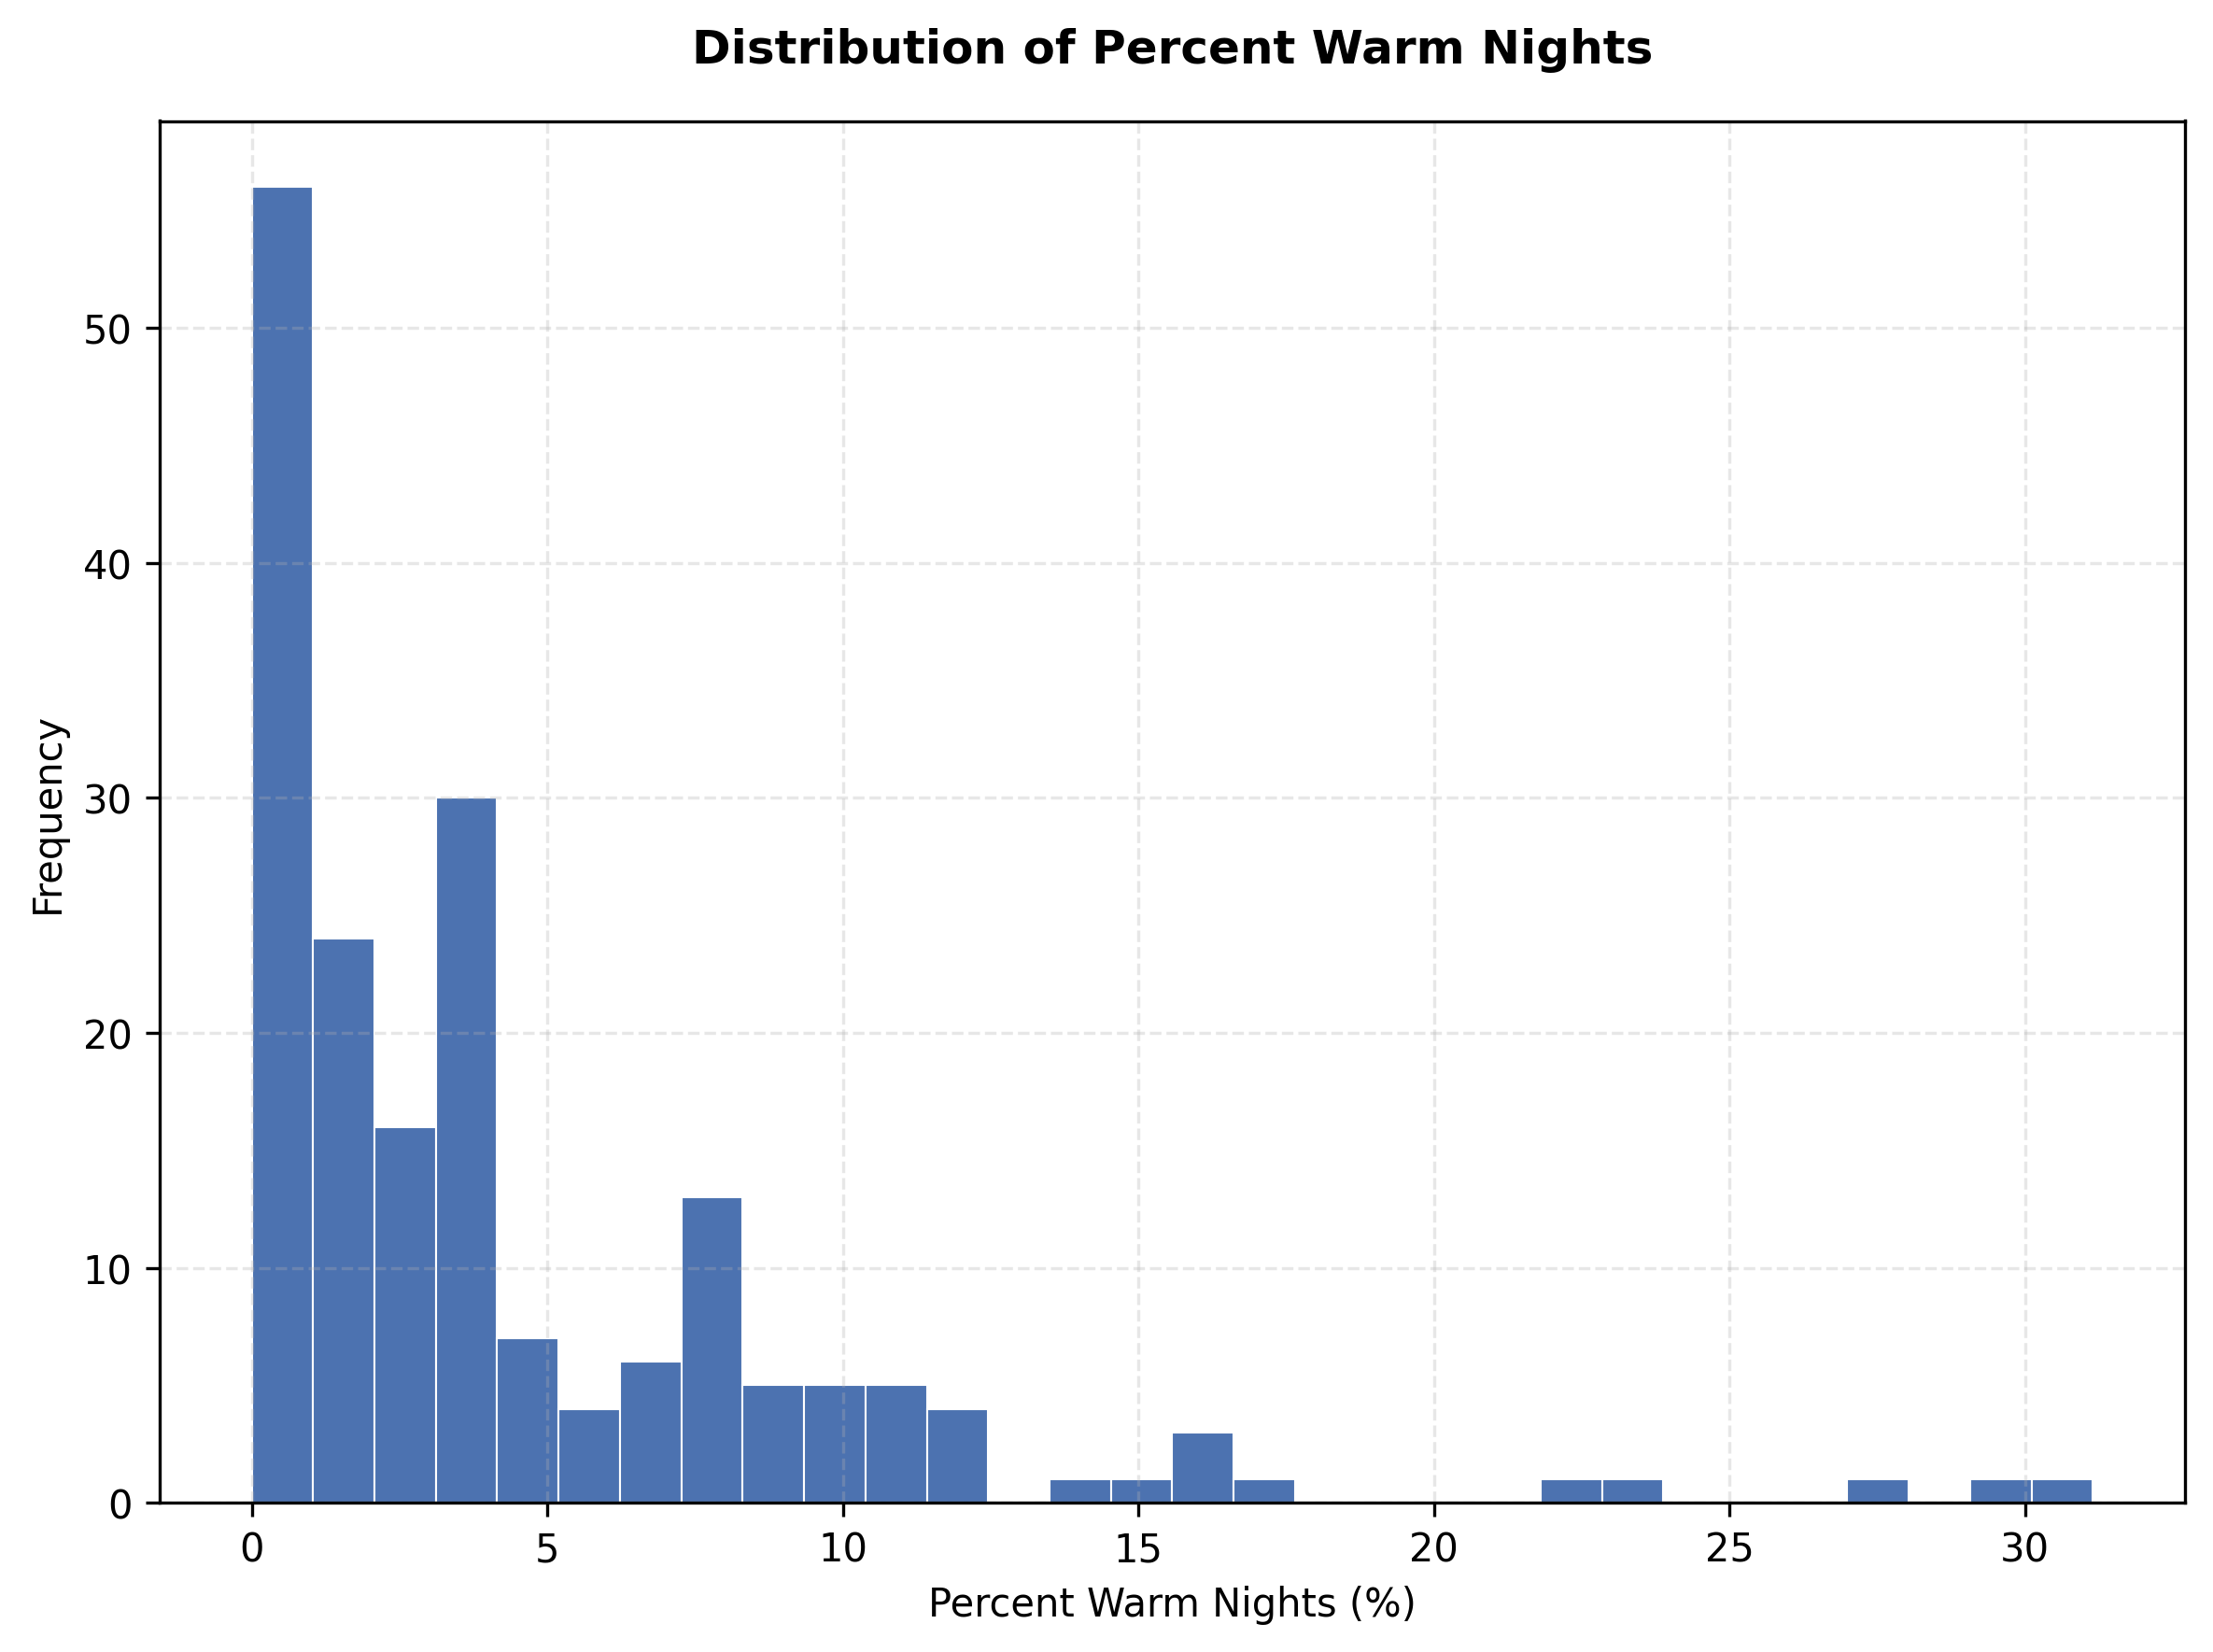

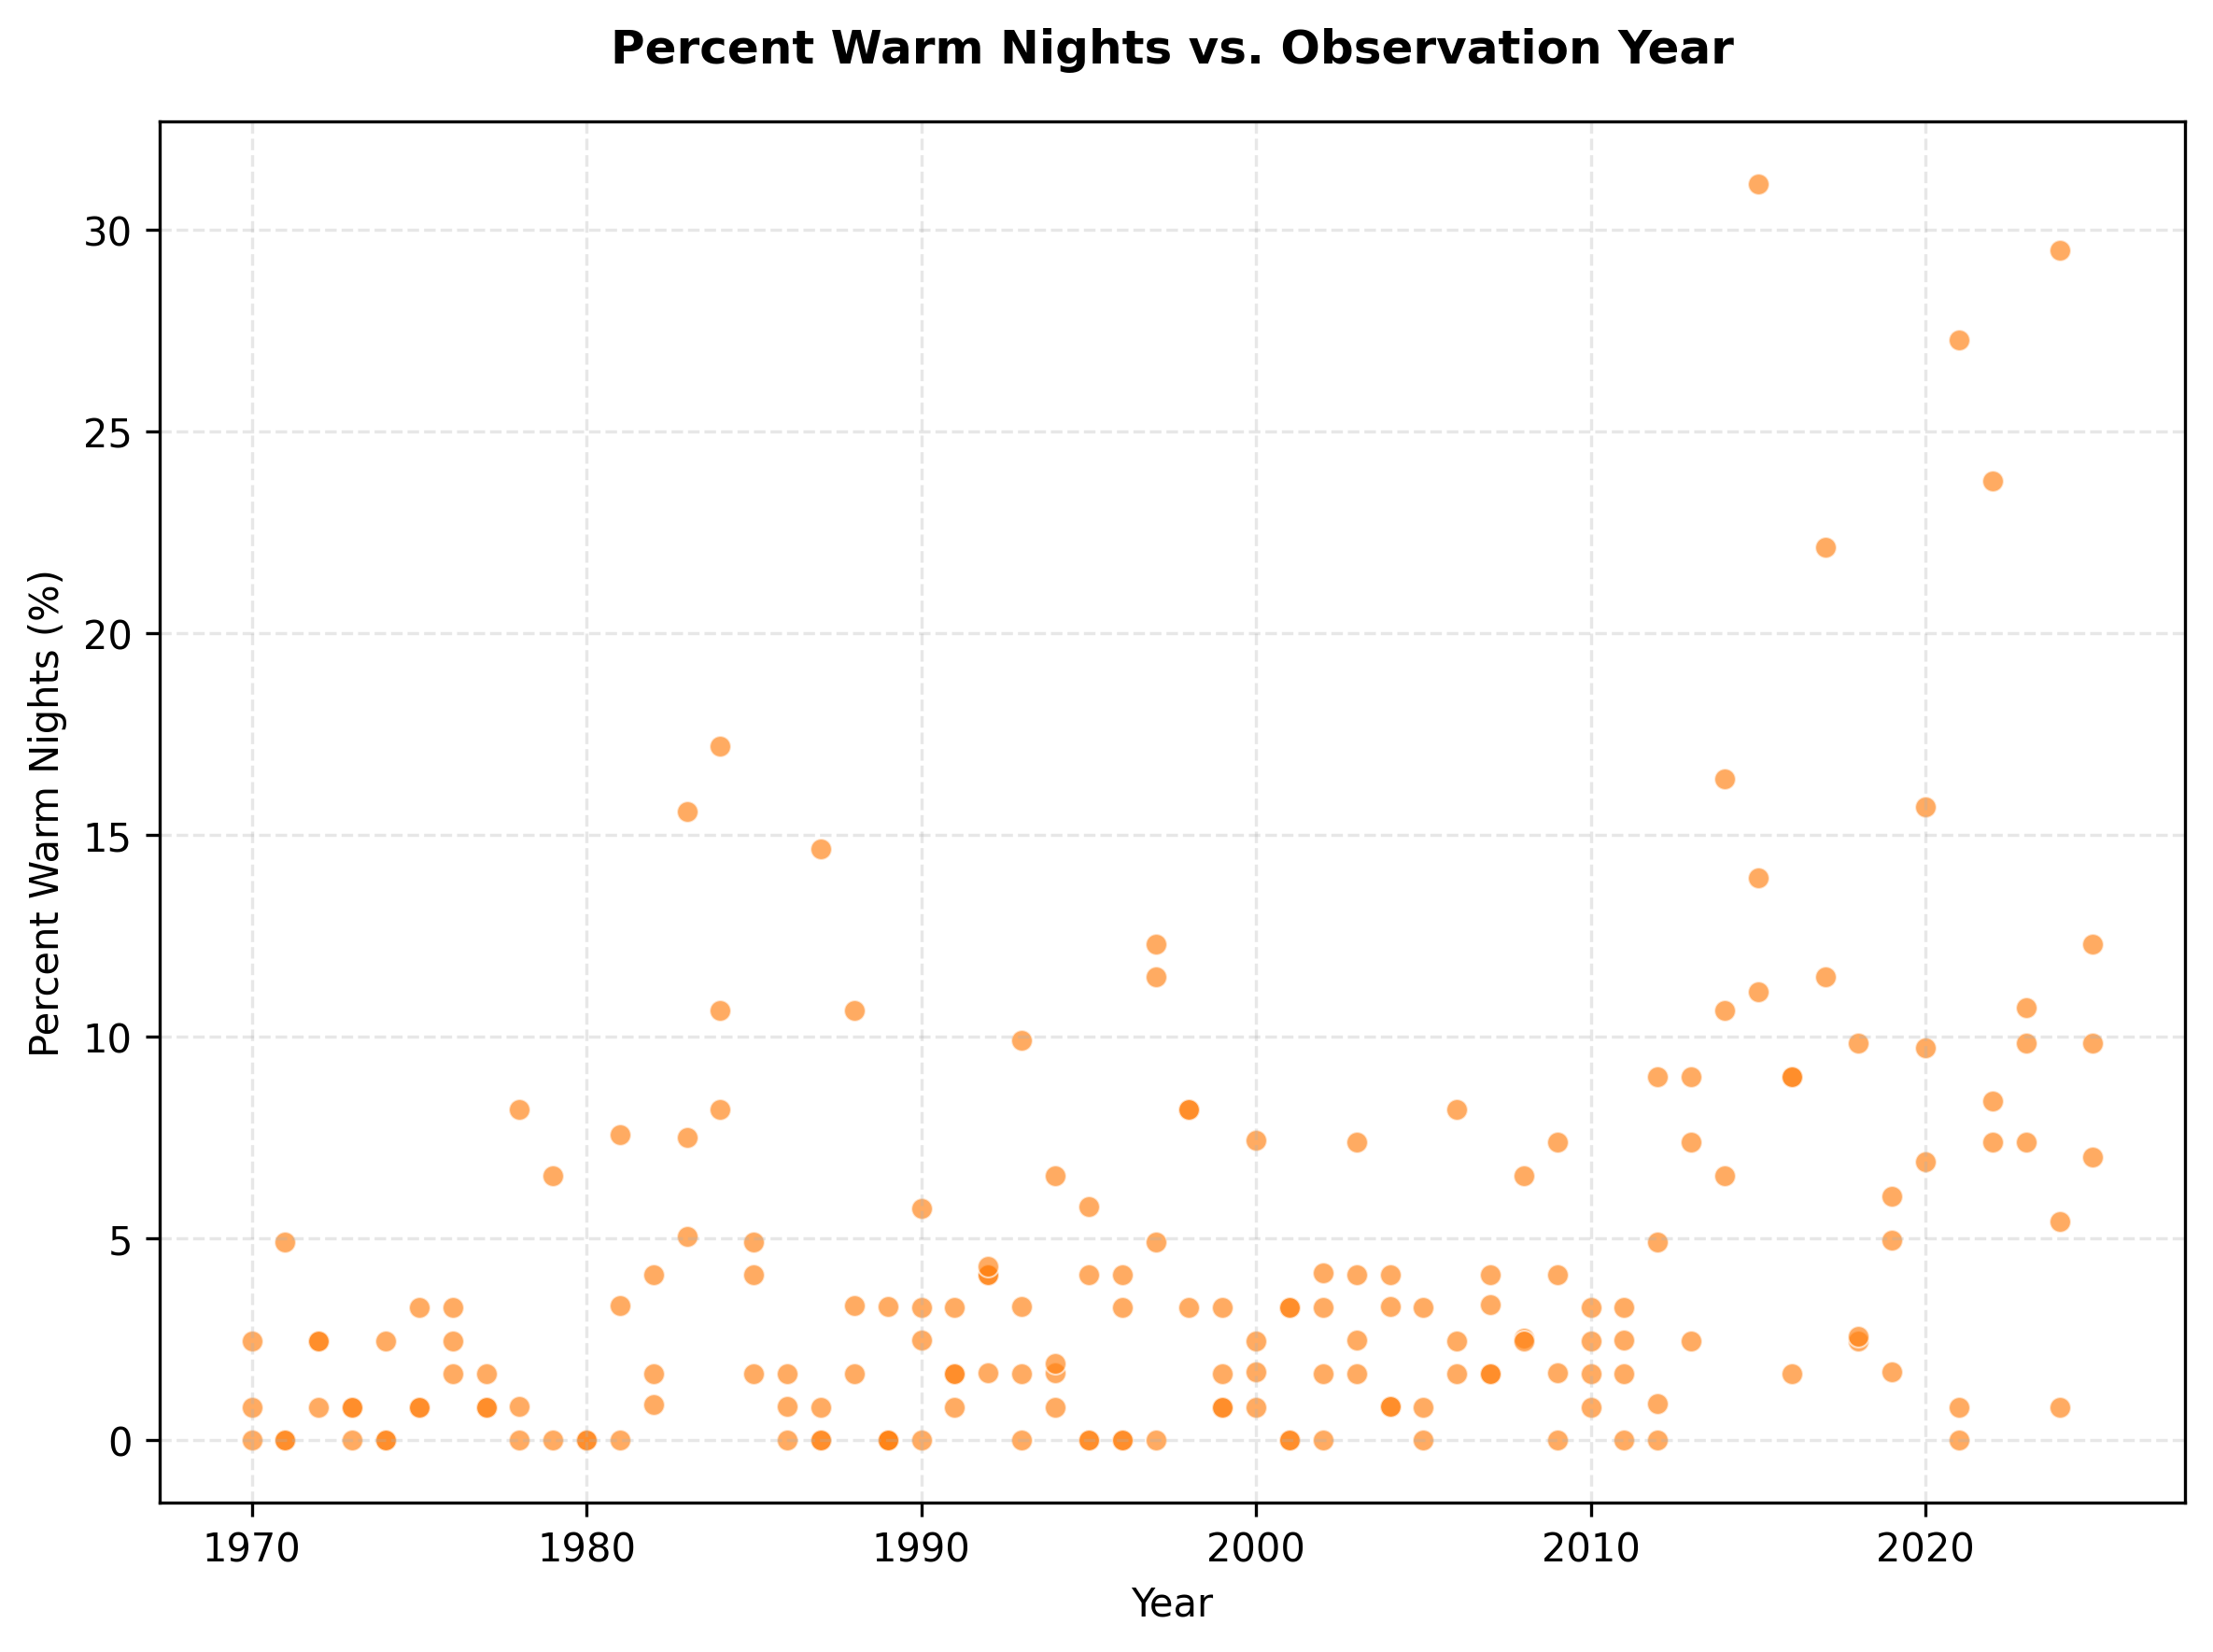

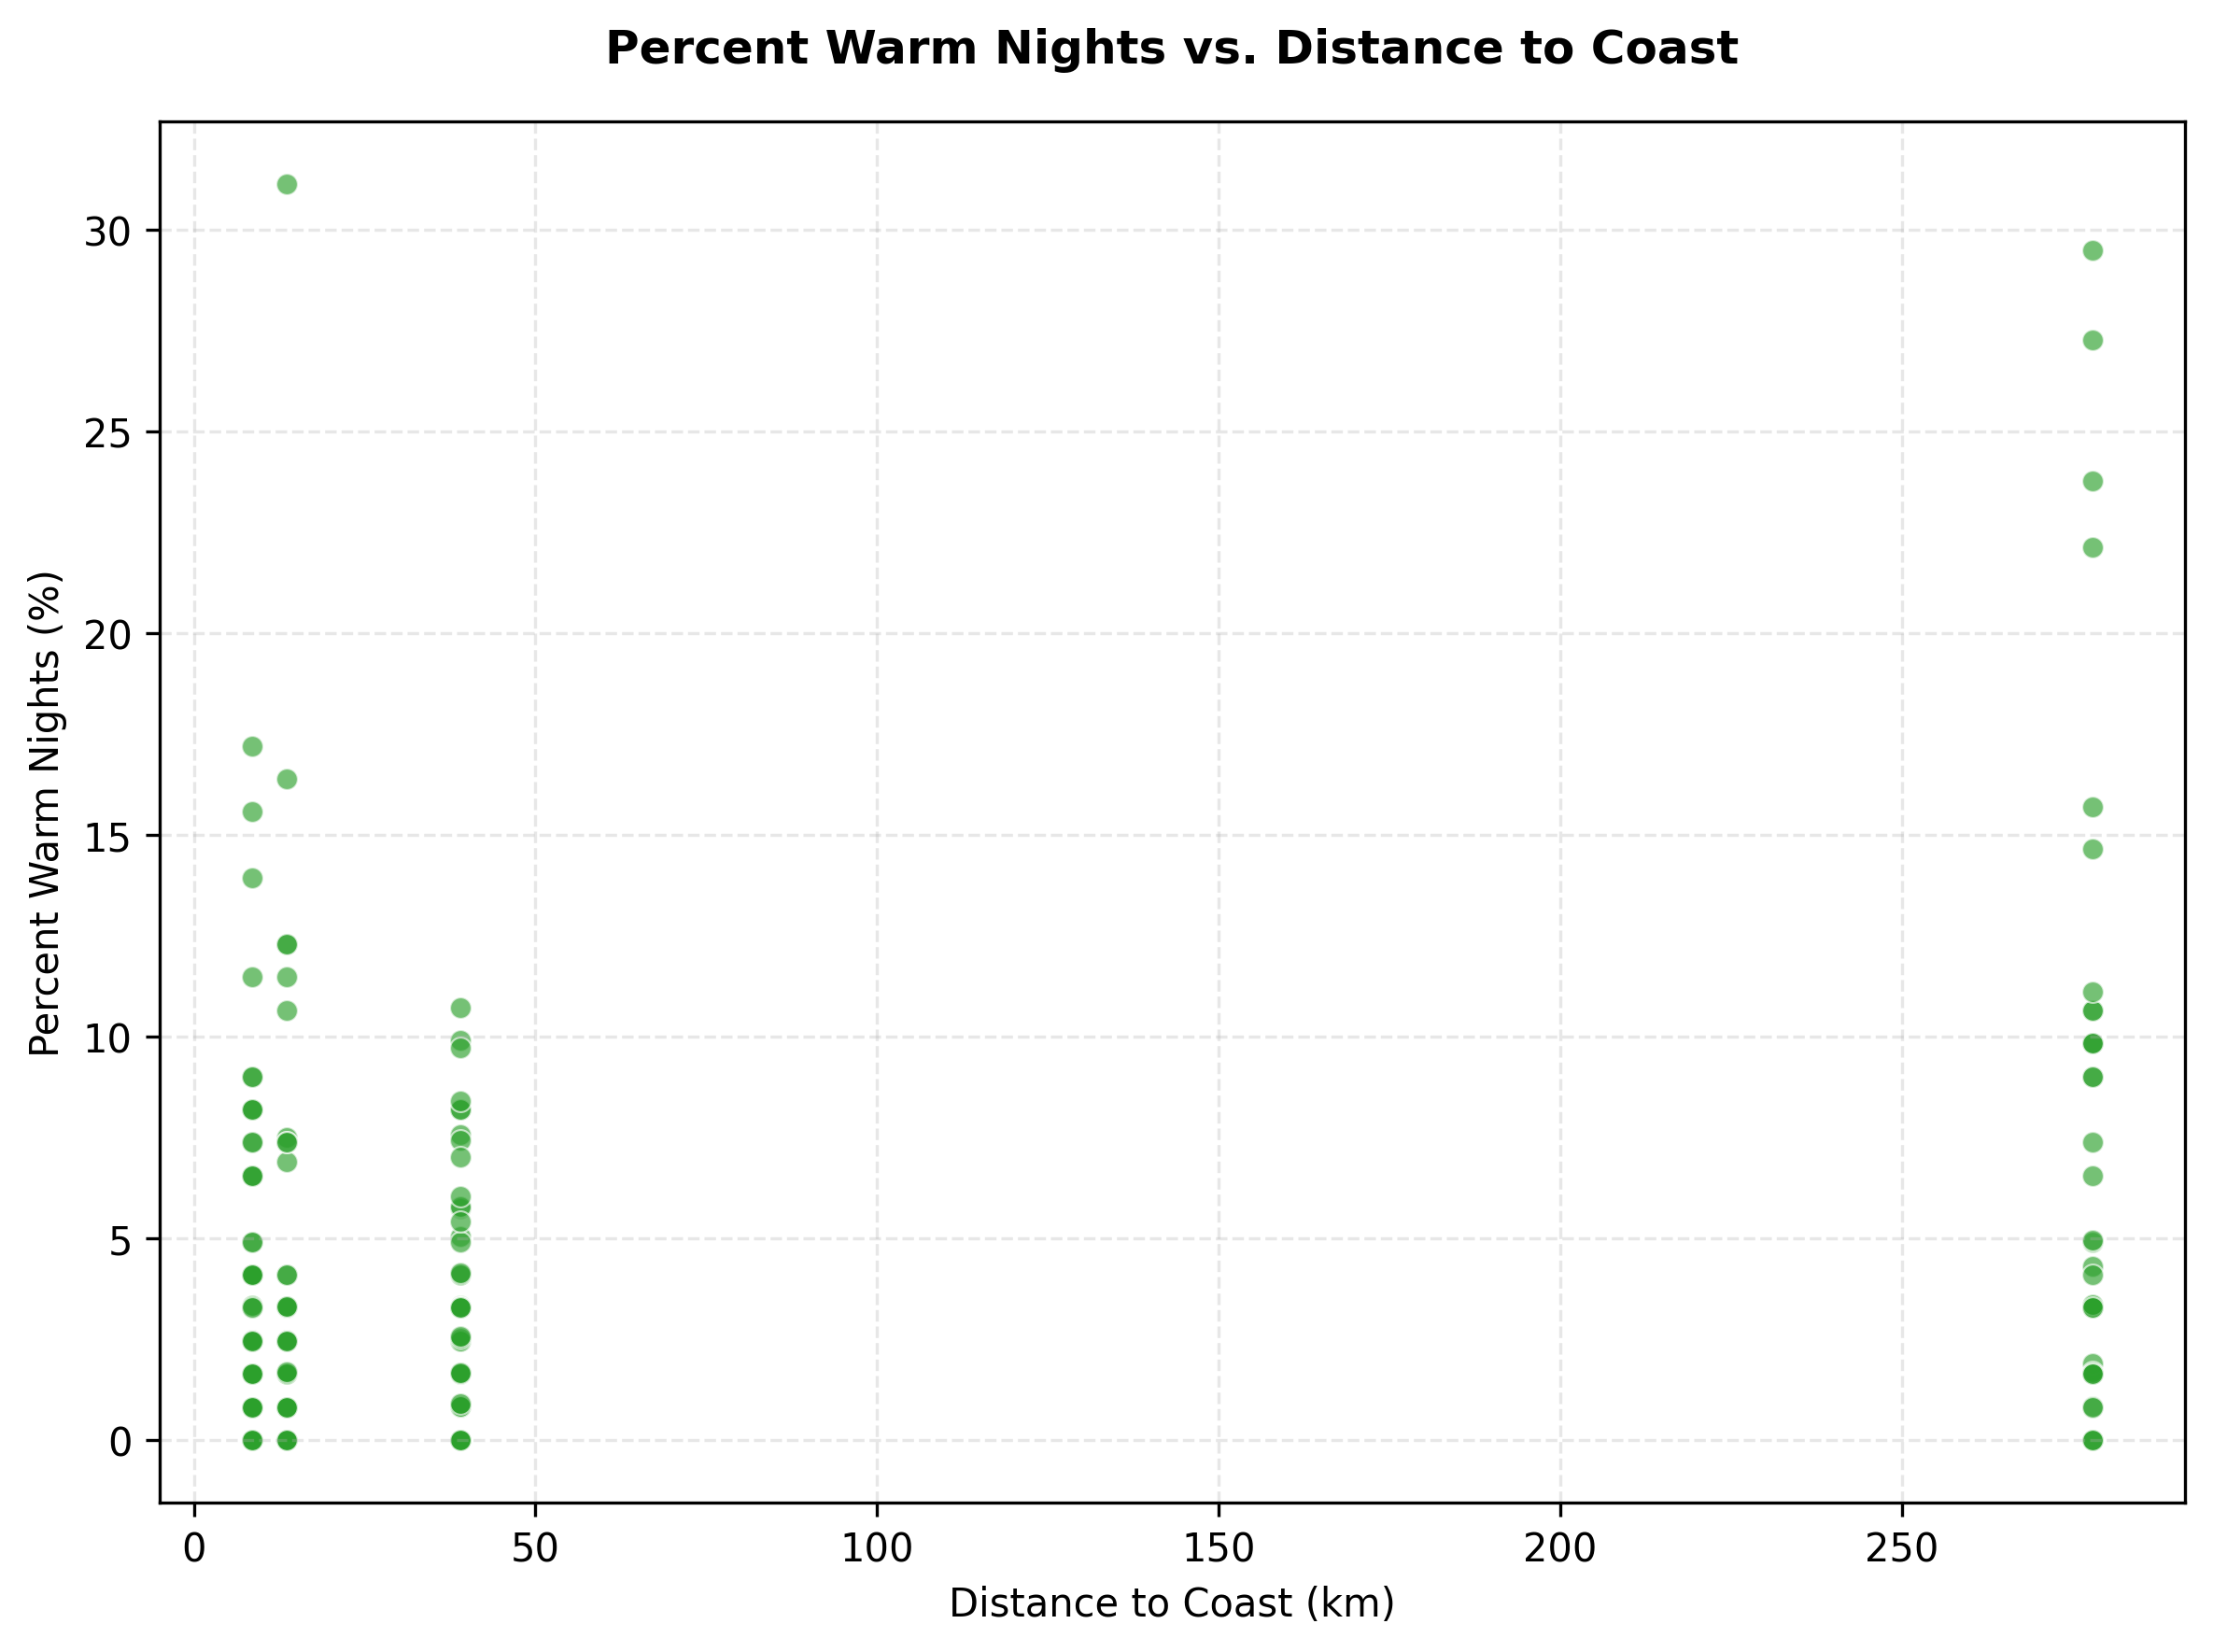

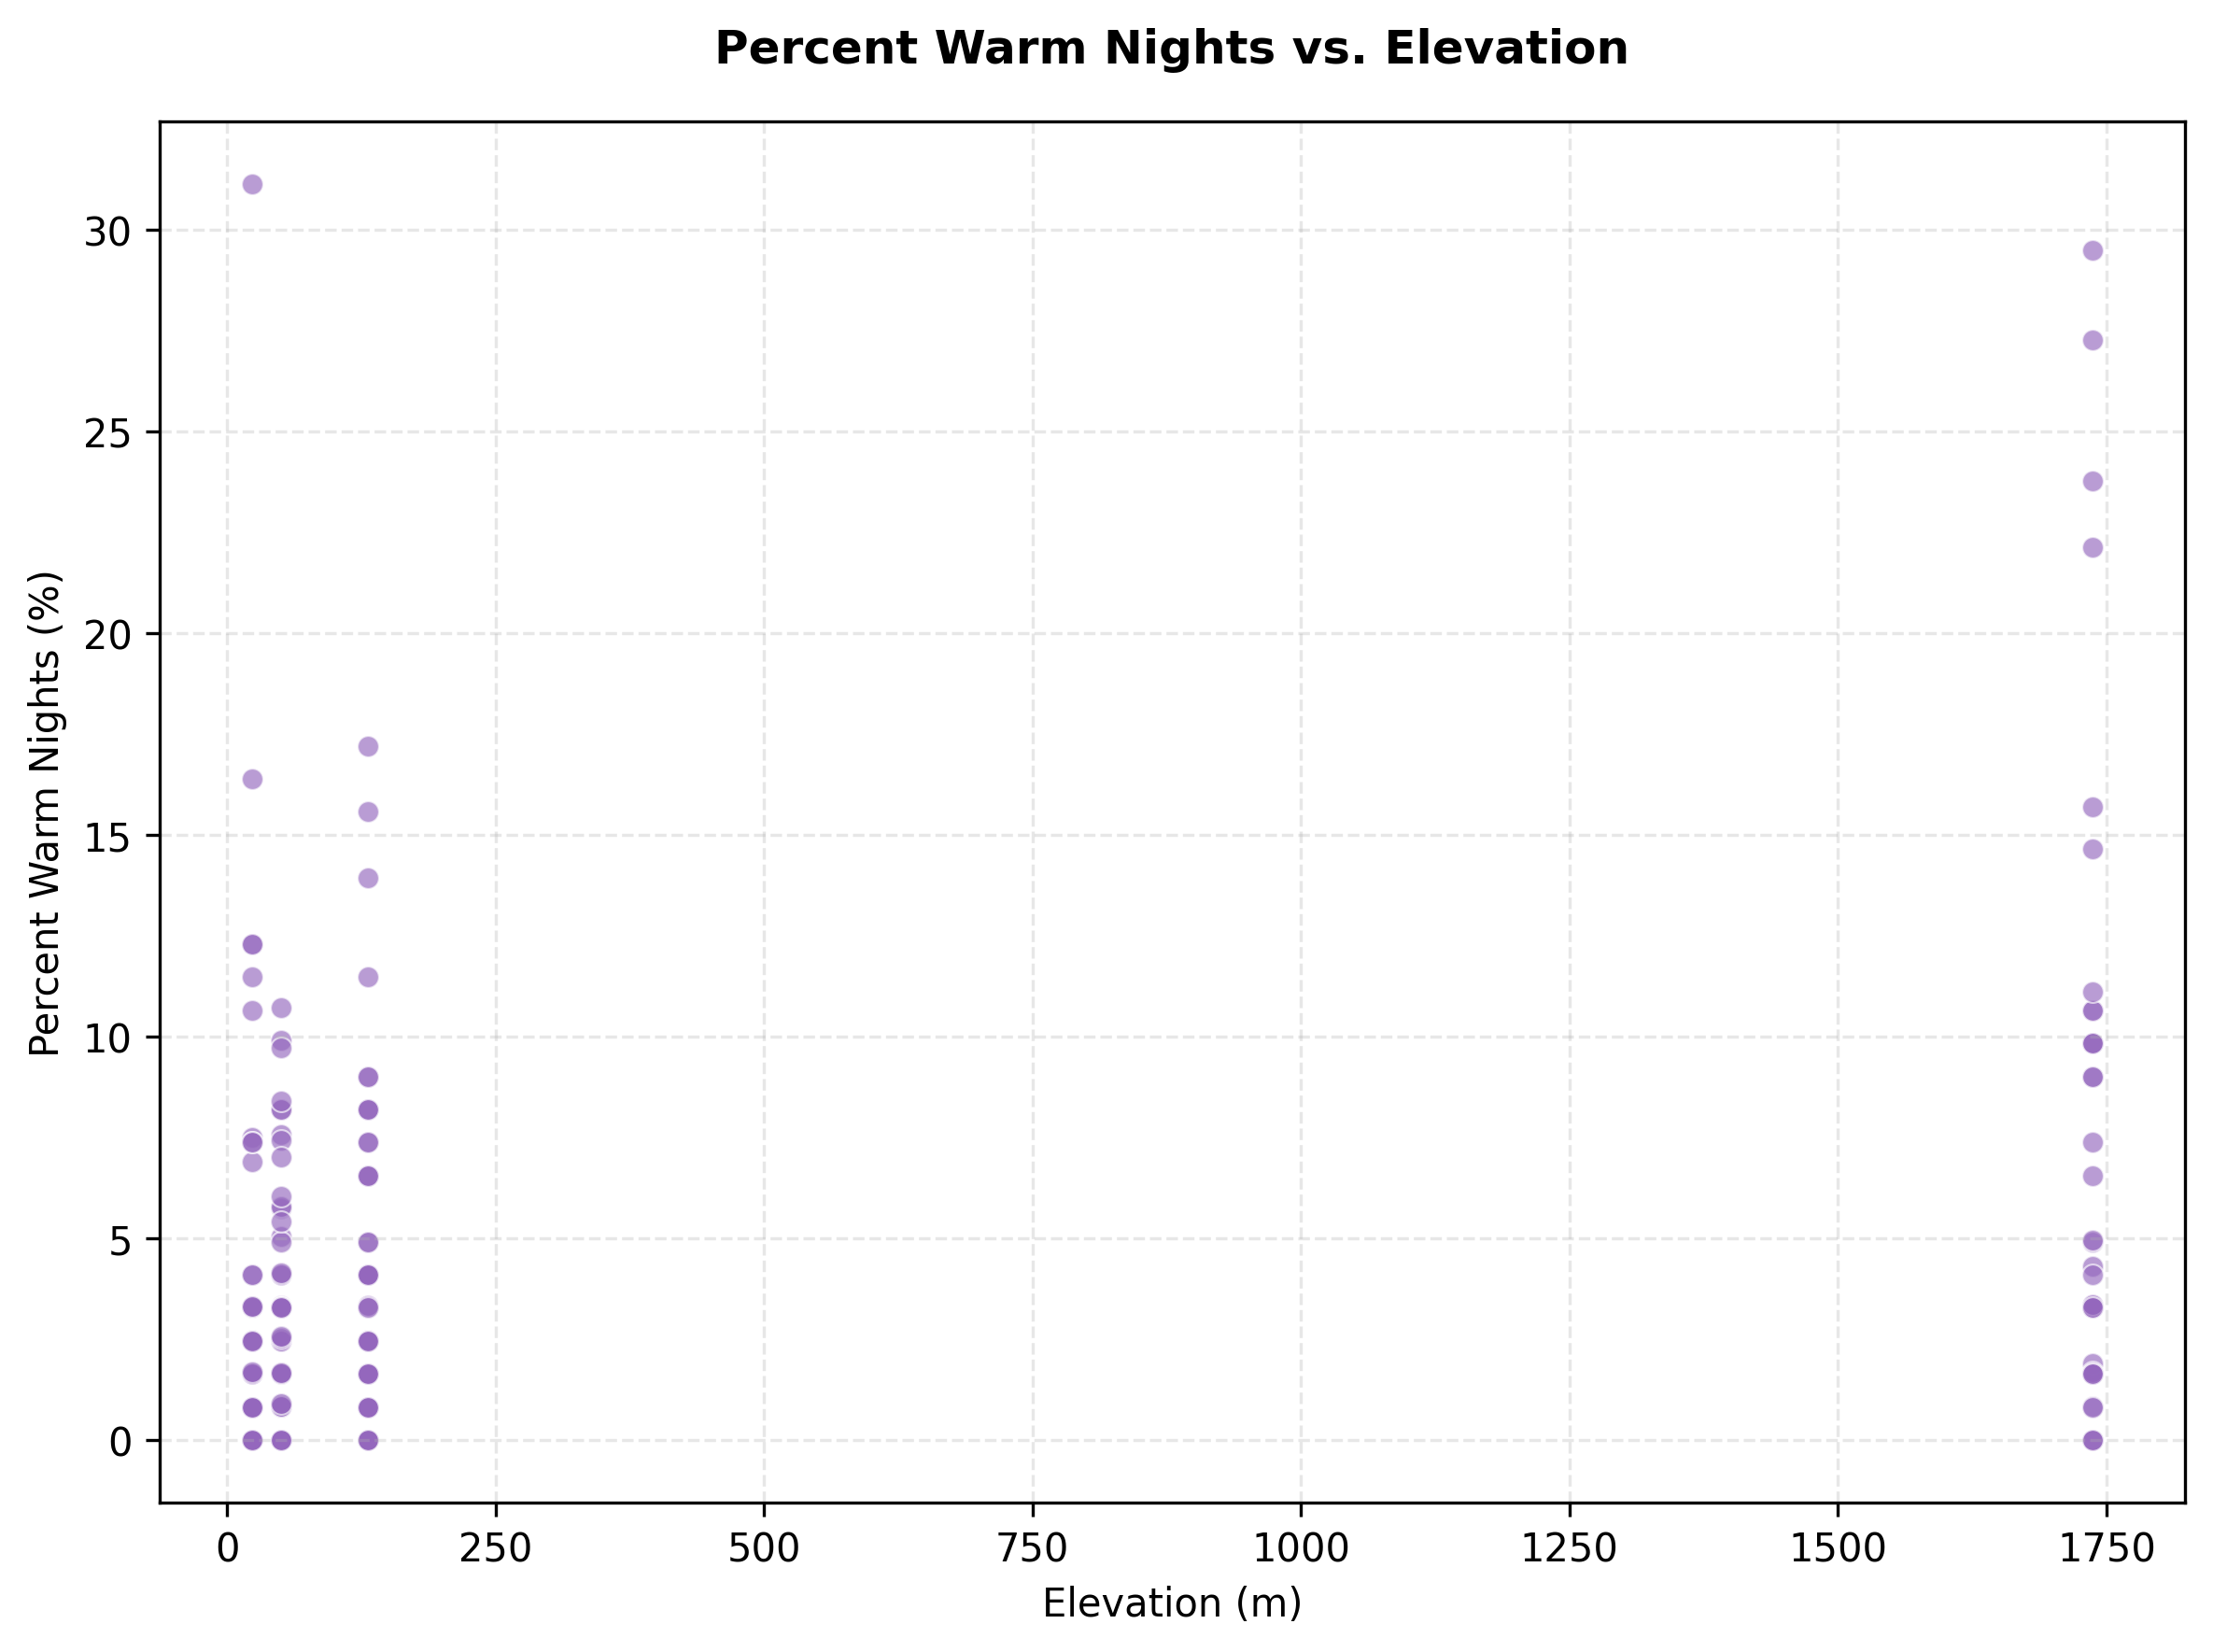

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

plt.figure(figsize=(8, 6), dpi=300, facecolor='white')

plt.hist(
    df['percent_warm_nights'].dropna(),
    bins=30,
    color='#4c72b0',
    edgecolor='white',
    linewidth=0.5,
)

plt.title('Distribution of Percent Warm Nights', fontsize=12, pad=15, fontweight='bold')
plt.xlabel('Percent Warm Nights (%)', fontsize=10)
plt.ylabel('Frequency', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()

plt.savefig('Figure_Dist_Warm_Nights.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

plt.figure(figsize=(8, 6), dpi=300, facecolor='white')

plt.scatter(
    df['year'],
    df['percent_warm_nights'],
    alpha=0.65,
    color='#ff7f0e',
    edgecolor='white',
    linewidth=0.5,
    s=30,
)

plt.title('Percent Warm Nights vs. Observation Year', fontsize=12, pad=15, fontweight='bold')
plt.xlabel('Year', fontsize=10)
plt.ylabel('Percent Warm Nights (%)', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()

plt.savefig('Figure_Warm_Nights_vs_Year.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

plt.figure(figsize=(8, 6), dpi=300, facecolor='white')

plt.scatter(
    df['distance_to_coast_km'],
    df['percent_warm_nights'],
    alpha=0.65,
    color='#2ca02c',
    edgecolor='white',
    linewidth=0.5,
    s=30,
)

plt.title('Percent Warm Nights vs. Distance to Coast', fontsize=12, pad=15, fontweight='bold')
plt.xlabel('Distance to Coast (km)', fontsize=10)
plt.ylabel('Percent Warm Nights (%)', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()

plt.savefig('Figure_Warm_Nights_vs_Coast.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

plt.figure(figsize=(8, 6), dpi=300, facecolor='white')

plt.scatter(
    df['elevation'],
    df['percent_warm_nights'],
    alpha=0.65,
    color='#9467bd',
    edgecolor='white',
    linewidth=0.5,
    s=30,
)

plt.title('Percent Warm Nights vs. Elevation', fontsize=12, pad=15, fontweight='bold')
plt.xlabel('Elevation (m)', fontsize=10)
plt.ylabel('Percent Warm Nights (%)', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()

plt.savefig('Figure_Warm_Nights_vs_Elevation.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

In [ ]:
# Cell 7: Step 7 - Repeat Split 10 Times for Stability
# YOU DO NOT NEED TO RERUN THIS
maes, rmses, r2s = [], [], []

for seed in range(10):
  np.random.seed(seed)
  train_stns = np.random.choice(
      unique_stations, size=int(0.8 * len(unique_stations)), replace=False
  )
  tr_mask = df["station_id"].isin(train_stns)
  te_mask = ~tr_mask

  X_tr, y_tr = df.loc[tr_mask, features], df.loc[tr_mask, target]
  X_te, y_te = df.loc[te_mask, features], df.loc[te_mask, target]

  model = RandomForestRegressor(
      n_estimators=500, min_samples_leaf=5, random_state=42
  )
  model.fit(X_tr, y_tr)
  preds = model.predict(X_te)

  maes.append(mean_absolute_error(y_te, preds))
  rmses.append(np.sqrt(mean_squared_error(y_te, preds)))
  r2s.append(r2_score(y_te, preds))

print("--- Step 7: 10-Split Stability Results ---")
print(f"Average MAE: {np.mean(maes):.3f} (Range: {np.min(maes):.3f} - {np.max(maes):.3f})")
print(f"Average RMSE: {np.mean(rmses):.3f} (Range: {np.min(rmses):.3f} - {np.max(rmses):.3f})")
print(f"Average R²: {np.mean(r2s):.3f} (Range: {np.min(r2s):.3f} - {np.max(r2s):.3f})")

--- Step 7: 10-Split Stability Results ---
Average MAE: 3.380 (Range: 2.202 - 4.274)
Average RMSE: 5.033 (Range: 3.173 - 7.070)
Average R²: 0.084 (Range: -0.169 - 0.163)
